# Task 3: Heart Disease Prediction

## Objective

The objective of this project is to build a machine learning classification model that predicts whether a patient is at risk of heart disease.

### What this project covers

- Load and inspect the dataset
- Perform data cleaning
- Explore the data using visualizations
- Prepare features and target
- Train a Logistic Regression model
- Evaluate the model
- Visualize the Confusion Matrix and ROC Curve

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("HeartDiseaseTrain-Test.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1025, 14)


,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [4]:
print("Dataset Information:\n")
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nTarget Distribution:\n")
print(df["target"].value_counts())

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia               

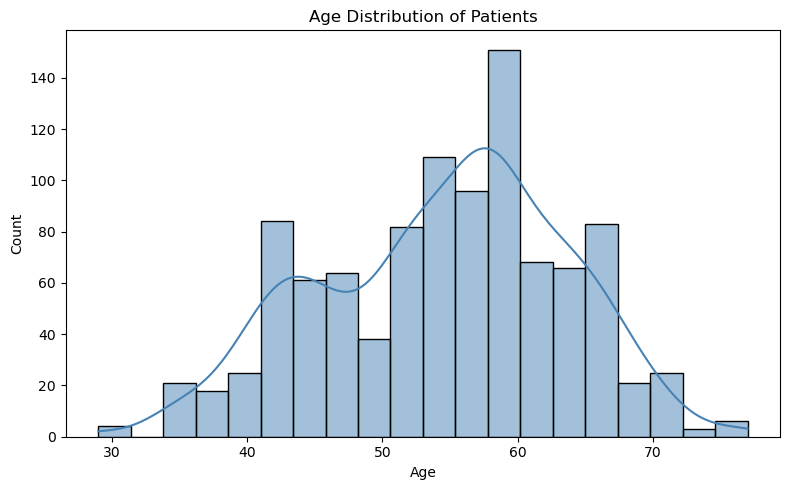

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [13]:
df_encoded = df.copy()

encoder = LabelEncoder()

categorical_columns = df_encoded.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    df_encoded[column] = encoder.fit_transform(df_encoded[column])

df_encoded.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,1,3,125,212,1,2,168,0,1.0,0,3,3,0
1,53,1,3,140,203,0,1,155,1,3.1,2,4,3,0
2,70,1,3,145,174,1,2,125,1,2.6,2,4,3,0
3,61,1,3,148,203,1,2,161,0,0.0,0,1,3,0
4,62,0,3,138,294,0,2,106,0,1.9,1,2,0,0


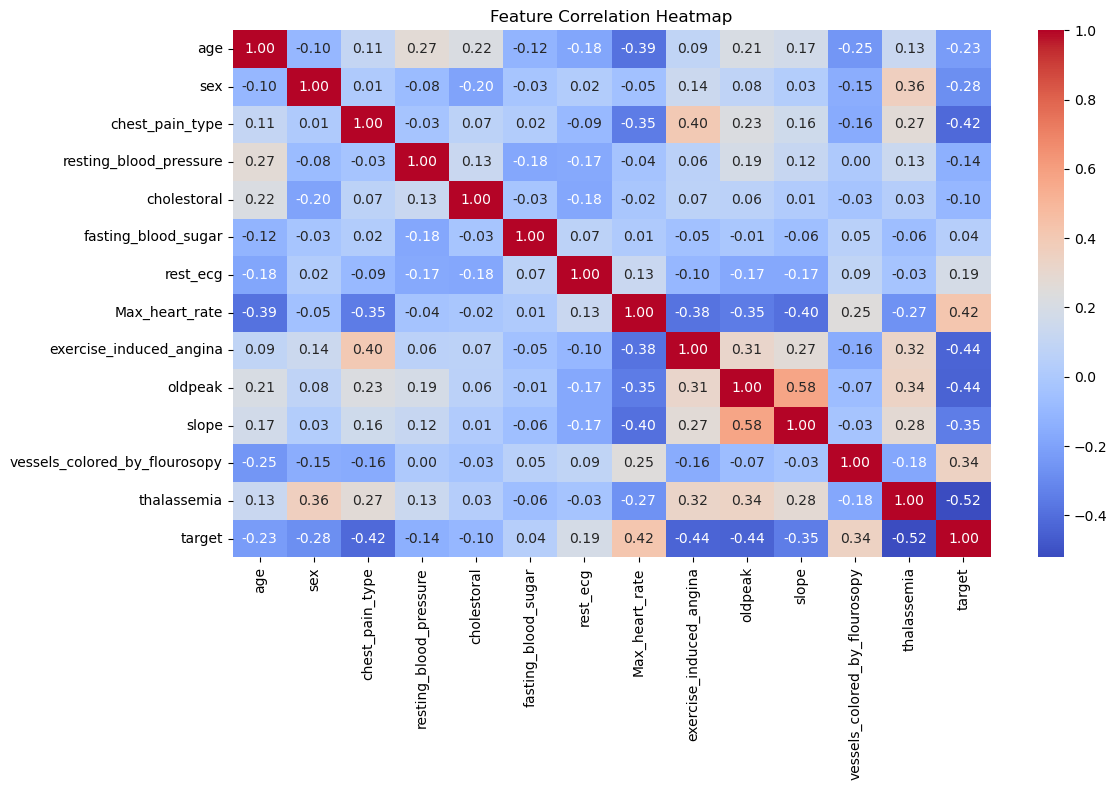

In [14]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.show()

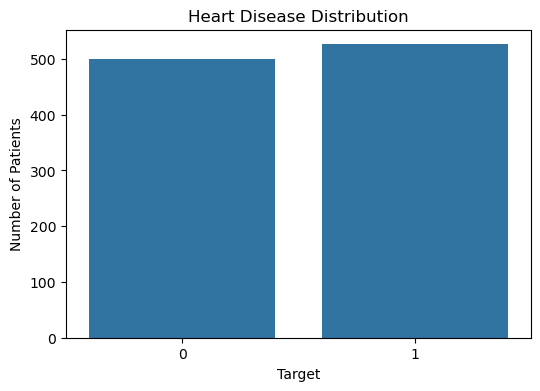

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="target",
    data=df
)

plt.title("Heart Disease Distribution")

plt.xlabel("Target")

plt.ylabel("Number of Patients")

plt.show()

In [16]:
X = df_encoded.drop("target", axis=1)

y = df_encoded["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [18]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [19]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy*100:.2f}%")

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy: 79.51%

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.75      0.78       102
           1       0.77      0.84      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



## Model Evaluation

The Logistic Regression model was evaluated using Accuracy and the Classification Report.

- **Accuracy** indicates the percentage of correct predictions.
- **Precision** measures how many predicted positive cases were actually positive.
- **Recall** measures how many actual positive cases were correctly identified.
- **F1-score** provides a balance between Precision and Recall.

Higher values indicate better model performance.

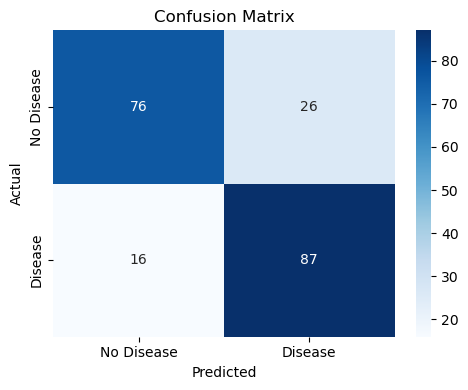

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease","Disease"],
    yticklabels=["No Disease","Disease"]
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()

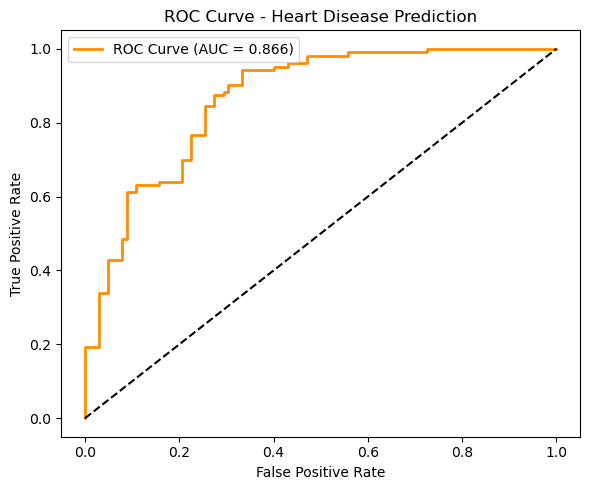

ROC-AUC Score: 0.866


In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"ROC Curve (AUC = {auc:.3f})"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Heart Disease Prediction")

plt.legend()

plt.tight_layout()

plt.show()

print(f"ROC-AUC Score: {auc:.3f}")

# Conclusion

## Objective Achieved

A Logistic Regression model was successfully developed to predict heart disease using patient health data.

### Key Findings

- The dataset was inspected and checked for missing values.
- Categorical features were encoded into numerical values.
- Three visualizations (Age Distribution, Correlation Heatmap, and Target Distribution) were created to explore the dataset.
- The model was trained and evaluated using Accuracy, Classification Report, Confusion Matrix, and ROC-AUC Score.
- The results demonstrate the effectiveness of Logistic Regression for binary classification problems.

Overall, this project follows a complete machine learning classification workflow for predicting heart disease risk.